# PAYMENTS DATA EXPLORATION

In [0]:
# Import essential libraries for data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt

In [0]:
# Load payments data from CSV file into a DataFrame
# Show first 5 rows to preview the data structure
df_payments = pd.read_csv('/Volumes/retail_catalog/default/raw_data/Payments.csv')
df_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [0]:
# Display the shape (number of rows and columns) in the payments DataFrame
df_payments.shape

(103886, 5)

In [0]:
# Print column info, data types, and memory usage of the DataFrame
df_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [0]:
# Display summary statistics for numerical columns in payments DataFrame
df_payments.describe().T

,count,mean,std,min,25%,50%,75%,max
payment_sequential,103886.0,1.092679,0.706584,1.0,1.00,1.0,1.0000,29.00
payment_installments,103886.0,2.853349,2.687051,0.0,1.00,1.0,4.0000,24.00
payment_value,103886.0,154.100380,217.494064,0.0,56.79,100.0,171.8375,13664.08


In [0]:
# Count missing values (nulls) in each column
df_payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [0]:
# Count number of unique values in each column
df_payments.nunique()

order_id                99440
payment_sequential         29
payment_type                5
payment_installments       24
payment_value           29077
dtype: int64

In [0]:
# Display all unique payment types to understand payment method diversity
df_payments['payment_type'].unique()

array(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'],
      dtype=object)

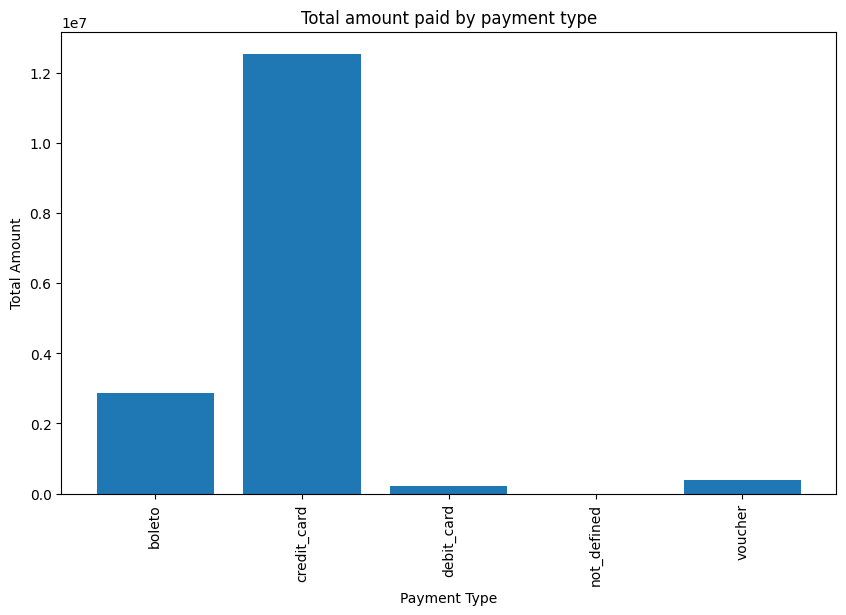

In [0]:
# Group payments by payment type and sum payment amounts
paymenttype_amount_sums = df_payments.groupby('payment_type')['payment_value'].sum()

# Visualize total amount paid by each payment type with a bar chart
plt.figure(figsize=(10, 6))
plt.bar(paymenttype_amount_sums.index, paymenttype_amount_sums.values)
plt.xticks(rotation=90)
plt.title('Total amount paid by payment type')
plt.xlabel('Payment Type')
plt.ylabel('Total Amount')
plt.show()
